In [83]:
pip install numpy matplotlib seaborn pandas scipy tqdm vtk

Note: you may need to restart the kernel to use updated packages.


In [84]:
import DiFfRG.file_io as io
import DiFfRG.plot as plt

import numpy as np
import math
from scipy.interpolate import make_interp_spline

folder = "./build/"
#folder = "./build/output_m2A_tuning/m2A_-7.319169921875e+00//"

m2A( 100.0 ) =  -107.028
m2A( 0.0002260329 ) =  0.07243275


/mnt/data/Documents/Uni/Code/DiFfRG-Applications/YangMills/SP/DiFfRG/plot.py:265: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc=legend_loc, borderpad=0.25, frameon=False)


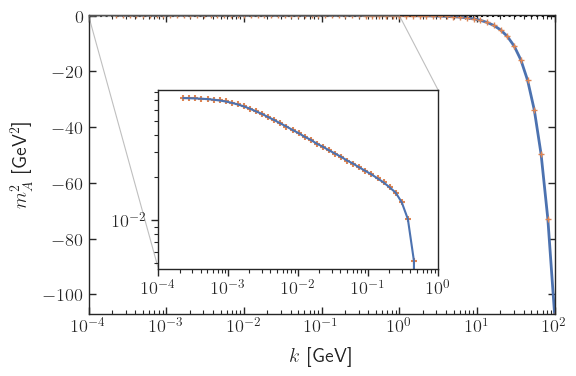

In [85]:
data = io.read_csv(folder + "output_data.csv")
kGeV = data["kGeV"].to_numpy()
t = data["t"].to_numpy()
m2A = data["m2A"].to_numpy()

print("m2A(",kGeV[0],") = ", m2A[0])
print("m2A(",kGeV[-1],") = ", m2A[-1])

def add_inset(ax):
  axins = ax.inset_axes([0.15, 0.15, 0.6, 0.6])
  axins.plot(kGeV, m2A)
  axins.scatter(kGeV, m2A, color=plt.palette1[1], marker="+")
  axins.set_xlim(1e-4, 1.0)
  #axins.set_ylim(np.min(m2A) / 10, m2A[-1] * 2)
  axins.set_xscale("log")
  axins.set_yscale("log")
  ax.indicate_inset_zoom(axins)

plt.plot_1D(
  [
    {
      "x": kGeV,
      "y": m2A,
      #"label": r"$m_A^2$",
      "scatter": False,
      "linewidth": 1,
    },
    {
      "x": kGeV,
      "y": m2A,
      #"label": r"$m_A^2$",
      "scatter": True,
    },
  ],
  modifiers=[
    add_inset,
    #make a dashed line at y = 0
    lambda ax : ax.axhline(0, color="black", linestyle="dotted"),
  ],
  log_x=True,
  #legend_loc="lower right",
  xlabel=r"$k$ [GeV]",
  ylabel=r"$m_A^2$ [GeV$^2$]",
  #file="m2A.pdf"
  xlim=[1e-4, np.max(kGeV)],
)

p_resc =  1.7112954151154471
Z_resc =  0.47813136277837576


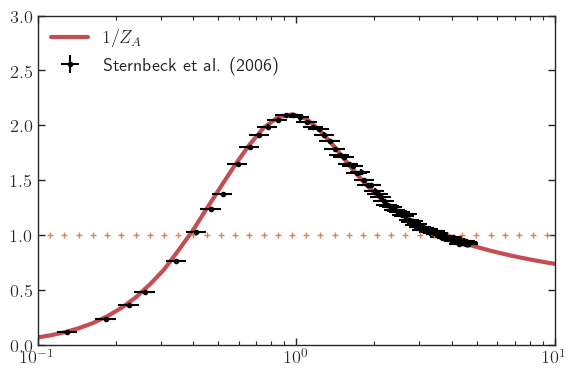

In [86]:
lat_dat = np.loadtxt("./sternbeck_2006_gluon.dat")
p_lat = lat_dat[:,0]
GA_lat = lat_dat[:,1]
err_lat = lat_dat[:,2]

lat2_dat = np.loadtxt("gluon_prop_R4GeV_128p4_b6p3.dat")
p_lat2 = lat2_dat[1:,0]
GA_lat2 = lat2_dat[1:,1]
ZAm1_lat2 = GA_lat2 * p_lat2**2
err_lat2 = lat2_dat[1:,2]
ZAm1_lat2_err = err_lat2 * p_lat2**2

lat2_dat = lat_dat
p_lat2 = lat_dat[:,0]
ZAm1_lat2 = lat_dat[:,1]
ZAm1_lat2_err = err_lat

kGeV, Zdat = io.read_k_csv(folder + "Zs.csv")
pGeV = Zdat[0]["pGeV"].to_numpy()
ZA = Zdat[0]["ZA"].to_numpy()

ZA_spl = make_interp_spline(pGeV, ZA, k=3)

def chi_sq(opt, cut_low = 0.8, cut_high = 4.0):
    p_resc = opt[0]
    Z_resc = opt[1]
    sel = np.logical_and(p_lat2 > cut_low, p_lat2 < cut_high)
    p_grid = p_lat2[sel]
    ZAm1_grid = ZAm1_lat2[sel]
    err_grid = ZAm1_lat2_err[sel]
    diff = (ZAm1_grid - Z_resc / ZA_spl(p_grid / p_resc))**2
    chi2 = np.sum(diff / err_grid) / (len(p_grid) - 2)

    p_max_lat = p_lat2[np.argmax(ZAm1_lat2)]
    p_max_lat = 0.955
    # find the maximum of the interpolated data
    better_p = np.linspace(0.5, 1.5, 1000)
    better_ZA = ZA_spl(better_p)
    p_max = better_p[np.argmin(better_ZA)] * p_resc

    return chi2 + (p_max - p_max_lat)**2 * 1e5

from scipy.optimize import minimize
p_resc, Z_resc = minimize(chi_sq, np.array([1, 0.7])).x

print("p_resc = ", p_resc)
print("Z_resc = ", Z_resc)
    
plt.plot_1D(
    [
        {
            "x": pGeV*p_resc,
            "y": 1 / ZA * Z_resc,
            "scatter": False,
            "color" : plt.palette1[3],
            "label": "$1 / Z_A$",
            "lw": 3
        },
        #{
         #   "x": pGeV*1.2,
          #  "y": 1 / ZA * 0.63,
           # "scatter": False,
        #},
        #{
        #    "x": p_lat,
        #    "y": GA_lat,
        #    "scatter": True,
        #    "yerr": err_lat,
        #    "color": "black",
        #    "label": "Sternbeck et al. (2006)"
        #},
        {
            "x": pGeV * p_resc,
            "y": pGeV * 0. + 1.,
            "scatter": True,
        },
        {
            "x": p_lat2,
            "y": ZAm1_lat2,
            "scatter": True,
            "yerr": ZAm1_lat2_err,
            "xerr": p_lat2*9e-2,
            "size": 3,
            "marker": "o",
            "color": "black",
            "label": "Sternbeck et al. (2006)"
        }
    ],
    log_x=True,
    xlim = [1e-1, 10],
    ylim = [0, 3],
    legend_loc="upper left",
)

maximum at p =  0.9628951410453885
kappa =  0.5713470219926535


/tmp/ipykernel_1210779/3009848373.py:26: RuntimeWarning: overflow encountered in power
  return A * p**(4 * kappa)


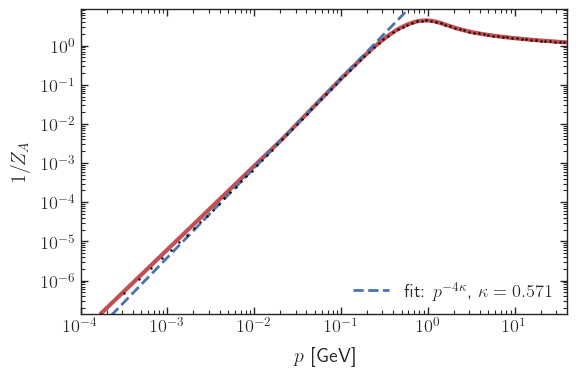

kappa =  0.5556873540037451


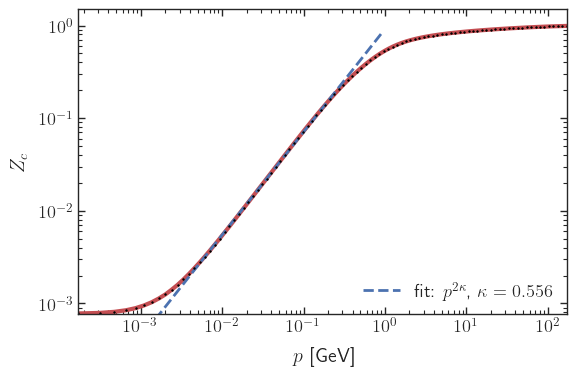

In [87]:
kGeV, Zdat = io.read_k_csv(folder + "Zs.csv")

pGeV = Zdat[0]["pGeV"].to_numpy()
ZA = Zdat[0]["ZA"].to_numpy()
ZAbar = Zdat[0]["ZAbar"].to_numpy()
Zc = Zdat[0]["Zc"].to_numpy()

kGeV, alphas = io.read_k_csv(folder + "strong_couplings.csv")
alphaAcbc = alphas[0]["alphaAcbc"].to_numpy()
alphaA3 = alphas[0]["alphaA3"].to_numpy()
alphaA4 = alphas[0]["alphaA4"].to_numpy()

pGeV = pGeV * p_resc

# find the value of p where ZA is smallest, using a spline interpolation
spl = make_interp_spline(pGeV, ZA, k=3)
better_p = np.linspace(pGeV.min(), pGeV.max(), 8000)
better_ZA = spl(better_p)
pMax = better_p[np.argmin(better_ZA)]
print("maximum at p = ", pMax)

# fit ZA with p^(-4 * kappa) using scipy curve_fit
from scipy.optimize import curve_fit

def fit_func(p, kappa, A):
    return A * p**(4 * kappa)

fit_max = 0.05

ZA_fit = 1 / ZA[pGeV < fit_max]
pGeV_fit = pGeV[pGeV < fit_max]
popt, pcov = curve_fit(fit_func, pGeV_fit, ZA_fit)
print("kappa = ", popt[0])

plt.plot_1D(
    [
        {
            "x": better_p,
            "y": 1 / better_ZA,
            "lw": 3,
            "color" : plt.palette1[3],
        },
        {
            "x": pGeV,
            "y": 1 / ZA,
            "scatter": True,
            "color" : "black",
            "size": 2,
        },
        # fit
        {
            "x": pGeV[pGeV < 1],
            "y": fit_func(pGeV[pGeV < 1], *popt),
            "label" : r"fit: $p^{-4 \kappa}$, " + rf"$\kappa = {popt[0]:.3f}$",
            "linestyle": "--",
            "color": plt.palette1[0],
        },
    ],
    log_x=True,
    log_y=True,
    grid=False,
    xlabel=r"$p$ [GeV]",
    ylabel=r"$1/Z_A$",
    ylim=[np.min(1 / ZA) * 0.99, 8.5],
    xlim=[1e-4, 40],
    legend_loc="lower right",
    #file="YM_ZA.pdf"
)

def fit_func(p, kappa, A):
    return A * p**(2 * kappa)

Zc_fit = Zc[pGeV < fit_max]
pGeV_fit = pGeV[pGeV < fit_max]
popt, pcov = curve_fit(fit_func, pGeV_fit, Zc_fit)
print("kappa = ", popt[0])

plt.plot_1D(
    [
        {
            "x": pGeV,
            "y": Zc,
            #"label" : r"$Z_c$",
            "lw": 3,
            "color": plt.palette1[3],
        },
        {
            "x": pGeV,
            "y": Zc,
            "scatter": True,
            "color" : "black",
            "size": 2,
        },
        # fit
        {
            "x": pGeV[pGeV < 1],
            "y": fit_func(pGeV[pGeV < 1], *popt),
            "label" : r"fit: $p^{2 \kappa}$, " + rf"$\kappa = {popt[0]:.3f}$",
            "linestyle": "--",
            "color": plt.palette1[0],
        },
    ],
    log_x=True,
    log_y=True,
    grid=False,
    ylim = [np.min(Zc)*0.99, 1.5],
    xlabel=r"$p$ [GeV]",
    ylabel=r"$Z_c$",
    legend_loc="lower right",
    #file="YM_Zc.pdf"
)

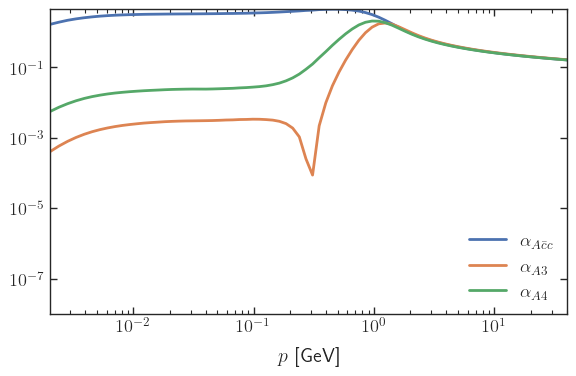

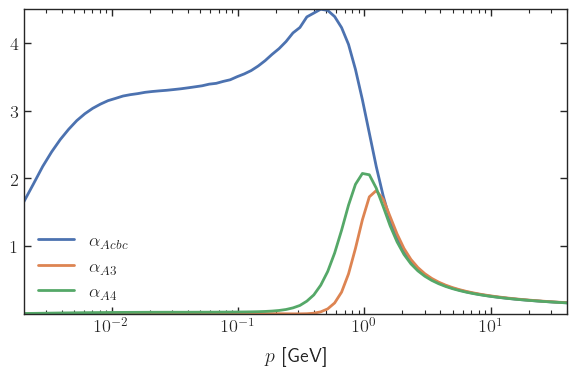

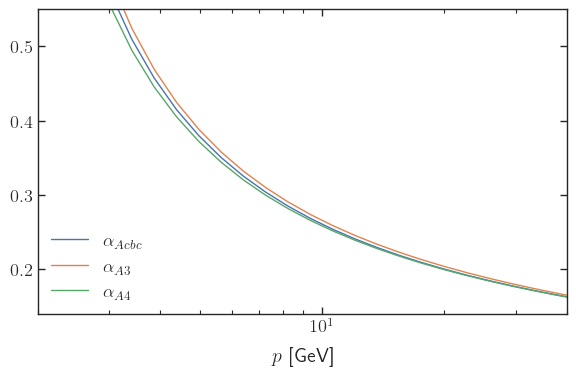

In [88]:
plt.plot_1D(
    [   
        {
            "x": pGeV,
            "y": alphaAcbc,
            "label" : r"$\alpha_{A\bar{c}c}$",
            "lw": 2,
        },
        {
            "x": pGeV,
            "y": alphaA3,
            "label" : r"$\alpha_{A3}$",
            "lw": 2,
        },
        {
            "x": pGeV,
            "y": alphaA4,
            "label" : r"$\alpha_{A4}$",
            "lw": 2,
        },
    ],
    log_x=True,
    log_y=True,
    grid=False,
    #ylim=[1e-5, 10],
    xlim=[2.01e-3, 40],
    xlabel=r"$p$ [GeV]",
    legend_loc="lower right",
    #file="YM_alphas.pdf"
)

plt.plot_1D(
    [   
        {
            "x": pGeV,
            "y": alphaAcbc,
            "label" : r"$\alpha_{Acbc}$",
            "linewidth": 1,
        },
        {
            "x": pGeV,
            "y": alphaA3,
            "label" : r"$\alpha_{A3}$",
            "linewidth": 1,
        },
        {
            "x": pGeV,
            "y": alphaA4,
            "label" : r"$\alpha_{A4}$",
            "linewidth": 1,
        },
    ],
    log_x=True,
    #log_y=True,
    grid=False,
    xlabel=r"$p$ [GeV]",
    xlim=[2.01e-3, 40],
    #ylim=[0.19, 0.8],
    #file="alphas_zoom.pdf"
)

plt.plot_1D(
    [   
        {
            "x": pGeV,
            "y": alphaAcbc,
            "label" : r"$\alpha_{Acbc}$",
            "lw": 1,
        },
        {
            "x": pGeV,
            "y": alphaA3,
            "label" : r"$\alpha_{A3}$",
            "lw": 1,
        },
        {
            "x": pGeV,
            "y": alphaA4,
            "label" : r"$\alpha_{A4}$",
            "lw": 1,
        },
    ],
    log_x=True,
    #log_y=True,
    grid=False,
    xlabel=r"$p$ [GeV]",
    xlim=[2, 40],
    ylim=[0.14, 0.55],
    #file="alphas_zoom.pdf"
)

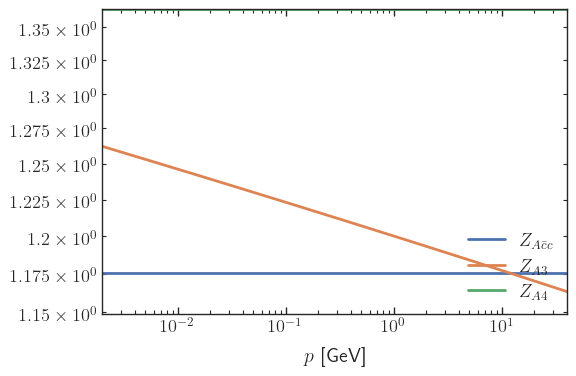

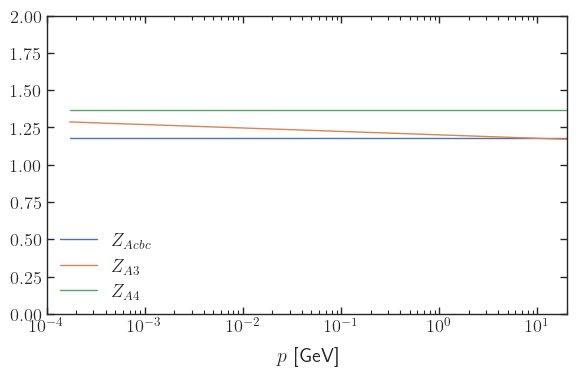

In [89]:
kGeV, alphas = io.read_k_csv(folder + "strong_couplings.csv")
ZAcbc = alphas[-1]["ZAcbc"].to_numpy()
ZA3 = alphas[-1]["ZA3"].to_numpy()
ZA4 = alphas[-1]["ZA4"].to_numpy()

plt.plot_1D(
    [   
        {
            "x": pGeV,
            "y": ZAcbc,
            "label" : r"$Z_{A\bar{c}c}$",
            "lw": 2,
        },
        {
            "x": pGeV,
            "y": ZA3,
            "label" : r"$Z_{A3}$",
            "lw": 2,
        },
        {
            "x": pGeV,
            "y": ZA4,
            "label" : r"$Z_{A4}$",
            "lw": 2,
        },
    ],
    log_x=True,
    log_y=True,
    grid=False,
    #ylim=[1e-5, 10],
    xlim=[2.01e-3, 40],
    xlabel=r"$p$ [GeV]",
    legend_loc="lower right",
    #file="YM_alphas.pdf"
)

plt.plot_1D(
    [   
        {
            "x": pGeV,
            "y": ZAcbc,
            "label" : r"$Z_{Acbc}$",
            "lw": 1,
        },
        {
            "x": pGeV,
            "y": ZA3,
            "label" : r"$Z_{A3}$",
            "lw": 1,
        },
        {
            "x": pGeV,
            "y": ZA4,
            "label" : r"$Z_{A4}$",
            "lw": 1,
        },
    ],
    log_x=True,
    #log_y=True,
    grid=False,
    xlabel=r"$p$ [GeV]",
    xlim=[1e-4, 20],
    ylim=[0, 2],
    #file="alphas_zoom.pdf"
)

/mnt/data/Documents/Uni/Code/DiFfRG-Applications/YangMills/SP/DiFfRG/plot.py:265: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc=legend_loc, borderpad=0.25, frameon=False)


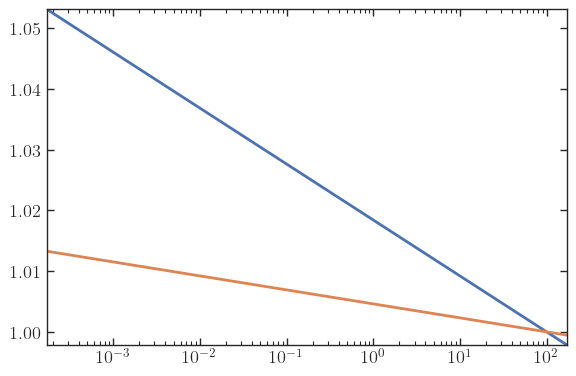

In [90]:
plt.plot_1D(
    [
        {
            "x": pGeV,
            "y": np.ones_like(pGeV) - 0.004*np.log(pGeV / 100),
        },
        {
            "x": pGeV,
            "y": np.ones_like(pGeV) - 0.001*np.log(pGeV / 100),
        }
    ],
    log_x=True
)